Chargement du dataset Iris depuis l'URL : https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv
Dataset chargé avec succès !

--- Aperçu des 5 premières lignes du dataset ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Dimensions du dataset (lignes, colonnes) ---
(150, 5)

--- Noms des colonnes ---
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

--- Types de données des colonnes ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- Analyse exploratoire des données ---

Statistiques

<Figure size 1000x700 with 0 Axes>

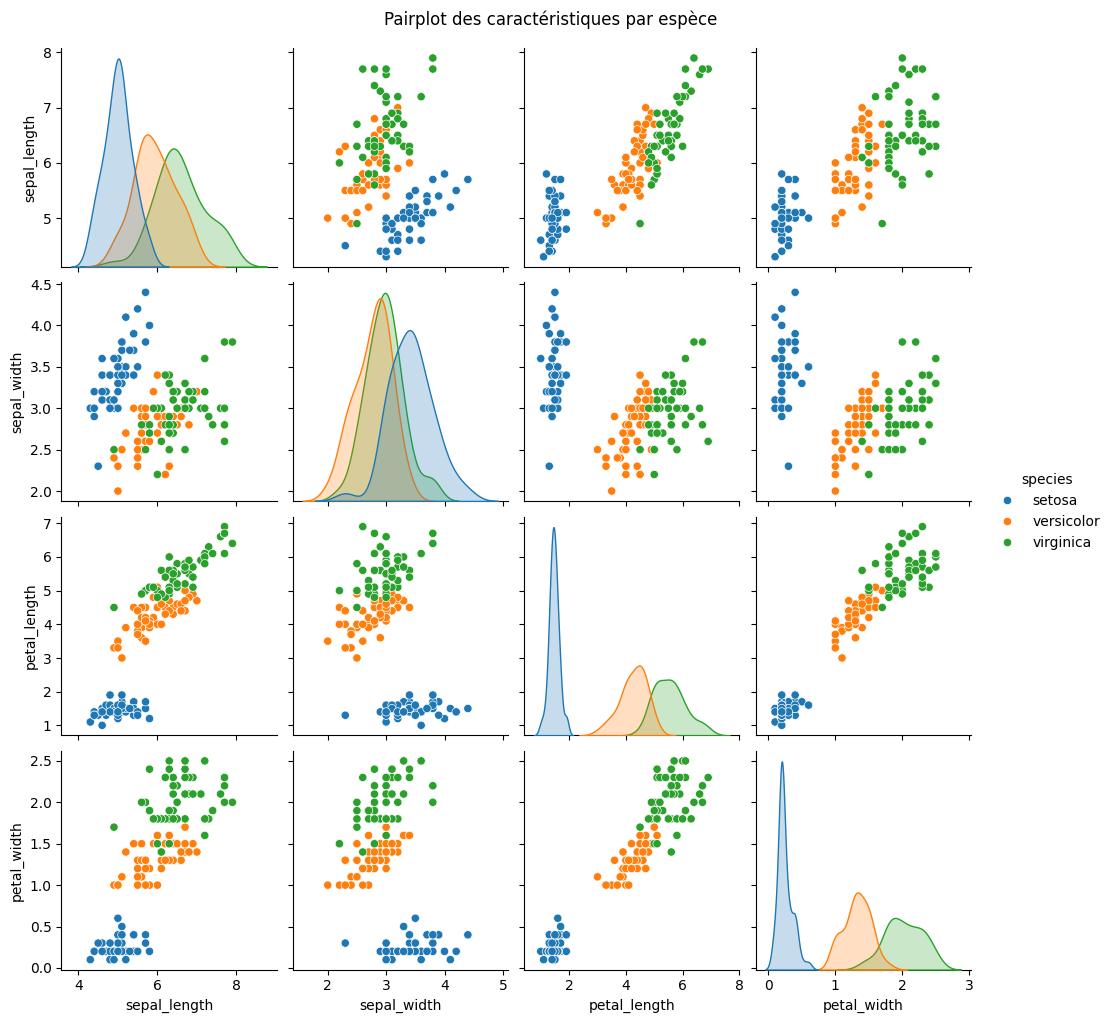

Le pairplot nous aide à visualiser les relations entre chaque paire de caractéristiques et comment les espèces se distinguent.

--- Définition de X (caractéristiques) et y (variable cible) ---
Variables utilisées comme caractéristiques (X) : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Variable cible (y) : 'species'
Aperçu de X (premières 5 lignes) :
    sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
Aperçu de y (premières 5 lignes) :
 0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

--- Prétraitement des données ---
La variable cible 'species' a été encodée en numérique :
Correspondance : ['setosa', 'versicolor', 'virginica'] -> [0 1 2]
Aperçu de

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


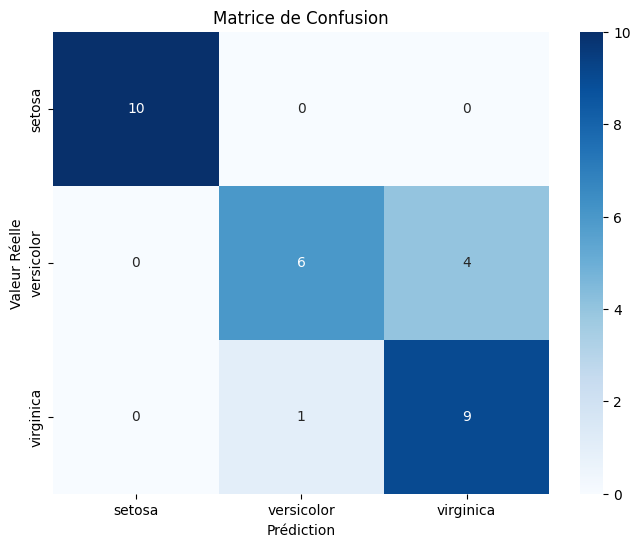

La matrice de confusion nous montre où le modèle se trompe. Les valeurs sur la diagonale sont les prédictions correctes.

--- Validation croisée (Cross-Validation) ---
Utilisation de la validation croisée (5 plis) pour évaluer la stabilité du modèle...
Scores d'accuracy obtenus sur chaque pli de la validation croisée : [0.83333333 0.93333333 0.93333333 0.83333333 1.        ]
Moyenne des scores d'accuracy en validation croisée : 0.9067
Écart-type des scores d'accuracy en validation croisée : 0.0646
La validation croisée nous donne une meilleure idée de la performance généralisée du modèle, en réduisant la dépendance à un seul split entraînement/test.
Une moyenne élevée et un faible écart-type indiquent un modèle stable et performant.

--- Exemple de prédiction sur de nouvelles données ---
Nouvelles données à prédire :
    sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           6.0          2.7           5.1          1.6

P

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [3]:
# -*- coding: utf-8 -*-
"""
Objectif :
Ce script présente un exemple concret de projet de Machine Learning,
de la préparation des données à la prédiction, en utilisant un modèle
de classification simple (régression logistique) sur le dataset Iris.
"""

# --- 1. Importation des bibliothèques nécessaires ---
# Nous importons toutes les bibliothèques que nous allons utiliser au début
# pour une meilleure lisibilité et organisation du code.
import pandas as pd # Pour la manipulation et l'analyse des données (DataFrames)
import numpy as np  # Pour les opérations numériques (tableaux N-dimensionnels)
import matplotlib.pyplot as plt # Pour la création de visualisations statiques
import seaborn as sns # Pour des visualisations statistiques plus esthétiques

from sklearn.model_selection import train_test_split, cross_val_score # Pour diviser les données et la validation croisée
from sklearn.preprocessing import StandardScaler, LabelEncoder # Pour la mise à l'échelle des caractéristiques et l'encodage des étiquettes
from sklearn.linear_model import LogisticRegression # Notre modèle de classification choisi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # Pour évaluer la performance du modèle

# --- 2. Chargement du dataset ---
# Nous allons utiliser le célèbre dataset Iris, qui est idéal pour un exemple
# de classification. Il est accessible directement via une URL publique.

# URL du dataset Iris en format CSV
dataset_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

print("Chargement du dataset Iris depuis l'URL :", dataset_url)

try:
    df = pd.read_csv(dataset_url)
    print("Dataset chargé avec succès !")
except Exception as e:
    print(f"Erreur lors du chargement du dataset : {e}")
    print("Veuillez vérifier l'URL ou votre connexion internet.")
    # En cas d'erreur, nous arrêtons l'exécution ou gérons l'exception autrement
    # Pour cet exemple pédagogique, nous allons simplement afficher l'erreur.
    exit()

# Affichage des premières lignes du dataset pour un aperçu
print("\n--- Aperçu des 5 premières lignes du dataset ---")
print(df.head())

# Affichage des dimensions du dataset (nombre de lignes, nombre de colonnes)
print("\n--- Dimensions du dataset (lignes, colonnes) ---")
print(df.shape)

# Affichage des noms des colonnes
print("\n--- Noms des colonnes ---")
print(df.columns)

# Affichage des types de données de chaque colonne
print("\n--- Types de données des colonnes ---")
print(df.dtypes)

# --- 3. Analyse exploratoire des données (EDA) ---
print("\n--- Analyse exploratoire des données ---")

# Statistiques descriptives pour les colonnes numériques
print("\nStatistiques descriptives :")
print(df.describe())

# Vérification des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())
# Le dataset Iris est généralement très propre et ne contient pas de valeurs manquantes.
# Si c'était le cas, des étapes de traitement des valeurs manquantes seraient nécessaires
# (ex: imputation par la moyenne, la médiane, suppression des lignes, etc.).

# Distribution de la variable cible ('species')
print("\nDistribution de la variable cible ('species') :")
print(df['species'].value_counts())
# Cela nous montre que chaque espèce est représentée équitablement, ce qui est bon pour l'entraînement.

# Visualisation de la distribution des caractéristiques et de leurs relations avec la variable cible
print("\nAffichage de quelques visualisations pertinentes...")
plt.figure(figsize=(10, 7))
sns.pairplot(df, hue='species')
plt.suptitle('Pairplot des caractéristiques par espèce', y=1.02) # y ajuste la position du titre
plt.show()
print("Le pairplot nous aide à visualiser les relations entre chaque paire de caractéristiques et comment les espèces se distinguent.")

# --- 4. Définition des caractéristiques (X) et de la variable cible (y) ---
# Les caractéristiques (X) sont les variables que nous utilisons pour prédire.
# La variable cible (y) est ce que nous voulons prédire.

X = df.drop('species', axis=1) # Toutes les colonnes sauf 'species'
y = df['species']             # La colonne 'species' est notre cible

print("\n--- Définition de X (caractéristiques) et y (variable cible) ---")
print("Variables utilisées comme caractéristiques (X) :", X.columns.tolist())
print("Variable cible (y) : 'species'")
print("Aperçu de X (premières 5 lignes) :\n", X.head())
print("Aperçu de y (premières 5 lignes) :\n", y.head())

# --- 5. Prétraitement des données ---
# Nous devons transformer la variable cible 'species' en valeurs numériques
# car les modèles de Machine Learning travaillent avec des nombres.
# Nous allons également mettre à l'échelle les caractéristiques.

# Encodage de la variable cible (Label Encoding)
# 'setosa' -> 0, 'versicolor' -> 1, 'virginica' -> 2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\n--- Prétraitement des données ---")
print("La variable cible 'species' a été encodée en numérique :")
print("Correspondance :", list(label_encoder.classes_), "->", np.unique(y_encoded))
print("Aperçu de y_encoded (premières 5 valeurs) :", y_encoded[:5])

# Normalisation/Standardisation des caractéristiques (StandardScaler)
# Cela assure que toutes les caractéristiques ont la même échelle, ce qui est
# important pour de nombreux algorithmes comme la régression logistique.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nLes caractéristiques (X) ont été standardisées (moyenne à 0, écart-type à 1).")
print("Aperçu de X_scaled (premières 5 lignes) :\n", X_scaled[:5])

# --- 6. Division des données en ensembles d'entraînement et de test ---
# Il est crucial de diviser nos données en deux parties :
# - Ensemble d'entraînement (80% des données) : utilisé pour entraîner le modèle.
# - Ensemble de test (20% des données) : utilisé pour évaluer la performance du modèle
#   sur des données qu'il n'a jamais vues, afin de juger sa capacité de généralisation.
# random_state=42 assure que la division est la même à chaque exécution, pour la reproductibilité.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
) # stratify=y_encoded assure que la proportion des classes est maintenue dans les splits

print("\n--- Division des données ---")
print(f"Taille de l'ensemble d'entraînement (X_train) : {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test) : {X_test.shape}")
print(f"Taille de l'ensemble d'entraînement (y_train) : {y_train.shape}")
print(f"Taille de l'ensemble de test (y_test) : {y_test.shape}")

# --- 7. Choix et entraînement du modèle ---
# Nous choisissons la Régression Logistique. C'est un algorithme de classification
# linéaire simple, efficace et facilement interprétable, parfait pour débuter.
# Il est bien adapté aux problèmes de classification binaire et multi-classes.

print("\n--- Choix et entraînement du modèle ---")
print("Algorithme choisi : Régression Logistique.")
print("Ce modèle est adapté car le dataset Iris est relativement simple et la régression logistique est un bon point de départ pour la classification.")

model = LogisticRegression(random_state=42, solver='liblinear', multi_class='auto')

print("Entraînement du modèle sur les données d'entraînement...")
model.fit(X_train, y_train)
print("Modèle entraîné avec succès !")

# --- 8. Prédictions sur l'ensemble de test ---
# Maintenant que le modèle est entraîné, nous l'utilisons pour faire des prédictions
# sur les données de test (que le modèle n'a jamais vues).
y_pred = model.predict(X_test)

print("\n--- Prédictions sur l'ensemble de test ---")
print("Aperçu des 10 premières prédictions :")
predictions_df = pd.DataFrame({
    'Réel (encodé)': y_test,
    'Prédit (encodé)': y_pred,
    'Réel (espèce)': label_encoder.inverse_transform(y_test),
    'Prédit (espèce)': label_encoder.inverse_transform(y_pred)
})
print(predictions_df.head(10))
print("Ces résultats montrent comment le modèle prédit l'espèce de l'iris en comparant avec la valeur réelle.")

# --- 9. Évaluation du modèle ---
# Pour savoir à quel point notre modèle est bon, nous utilisons des métriques d'évaluation.
# Pour la classification, les métriques clés incluent l'Accuracy, la Précision, le Rappel et le F1-score.

print("\n--- Évaluation du modèle ---")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # 'weighted' pour tenir compte du déséquilibre des classes
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy (Précision globale) : {accuracy:.4f}")
print(f"Precision (Précision par classe, pondérée) : {precision:.4f}")
print(f"Recall (Rappel par classe, pondéré) : {recall:.4f}")
print(f"F1-score (Moyenne harmonique Précision et Rappel) : {f1:.4f}")

print("\nInterprétation des métriques :")
print("- L'Accuracy indique la proportion de prédictions correctes sur l'ensemble des prédictions.")
print("- La Précision mesure la proportion de vrais positifs parmi toutes les prédictions positives. Un score élevé signifie peu de faux positifs.")
print("- Le Rappel mesure la proportion de vrais positifs parmi tous les cas réels positifs. Un score élevé signifie peu de faux négatifs.")
print("- Le F1-score est une moyenne pondérée de la Précision et du Rappel, utile quand on cherche un équilibre entre les deux.")

# Matrice de confusion : un tableau montrant les vrais positifs/négatifs et faux positifs/négatifs
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :")
print(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Prédiction')
plt.ylabel('Valeur Réelle')
plt.title('Matrice de Confusion')
plt.show()
print("La matrice de confusion nous montre où le modèle se trompe. Les valeurs sur la diagonale sont les prédictions correctes.")

# --- 10. Validation croisée ---
# La validation croisée est une technique robuste pour évaluer la performance
# du modèle en divisant les données en plusieurs 'folds' (plis) et en entraînant
# et testant le modèle sur différentes combinaisons de ces folds. Cela permet
# d'obtenir une estimation plus stable et fiable de la performance du modèle.

print("\n--- Validation croisée (Cross-Validation) ---")
print("Utilisation de la validation croisée (5 plis) pour évaluer la stabilité du modèle...")

cv_scores = cross_val_score(model, X_scaled, y_encoded, cv=5, scoring='accuracy')

print("Scores d'accuracy obtenus sur chaque pli de la validation croisée :", cv_scores)
print(f"Moyenne des scores d'accuracy en validation croisée : {cv_scores.mean():.4f}")
print(f"Écart-type des scores d'accuracy en validation croisée : {cv_scores.std():.4f}")

print("La validation croisée nous donne une meilleure idée de la performance généralisée du modèle, en réduisant la dépendance à un seul split entraînement/test.")
print("Une moyenne élevée et un faible écart-type indiquent un modèle stable et performant.")

# --- 11. Exemple concret de prédiction avec de nouvelles données ---
# C'est l'étape finale et la plus importante : montrer comment utiliser le modèle
# entraîné pour faire des prédictions sur de nouvelles données réelles.

print("\n--- Exemple de prédiction sur de nouvelles données ---")

# Création de nouvelles données (hypotétiques) à prédire.
# Les colonnes doivent correspondre aux caractéristiques utilisées pour l'entraînement.
# Il est crucial d'utiliser les mêmes noms de colonnes et le même ordre.
new_data = pd.DataFrame({
    'sepal_length': [5.1, 6.0],
    'sepal_width': [3.5, 2.7],
    'petal_length': [1.4, 5.1],
    'petal_width': [0.2, 1.6]
})

print("Nouvelles données à prédire :\n", new_data)

# IMPORTANT : Il faut appliquer les mêmes transformations (scaling) aux nouvelles données
# que celles appliquées aux données d'entraînement. Nous utilisons le même 'scaler' entraîné.
new_data_scaled = scaler.transform(new_data)

# Effectuer la prédiction avec le modèle entraîné
final_prediction_encoded = model.predict(new_data_scaled)

# Convertir les prédictions numériques encodées en noms d'espèces lisibles
final_prediction_species = label_encoder.inverse_transform(final_prediction_encoded)

print("\nPrédiction du modèle pour les nouvelles données :")
for i, (data_point, species_pred) in enumerate(zip(new_data.values, final_prediction_species)):
    print(f"  - Pour le point de données {data_point.tolist()}, l'espèce prédite est : {species_pred}")

print("\nExplication : Le modèle prend les caractéristiques des nouvelles données (longueur/largeur des sépales et pétales),")
print("les met à l'échelle de la même manière que les données d'entraînement, puis utilise ce qu'il a appris pour prédire l'espèce d'iris la plus probable pour chaque nouveau point.")
print("Ceci conclut notre exemple de projet de Machine Learning.")